# Adding NPIs to the SEIHRV model

## Using multiple functions and time arrays

Now that we can simulate the effect of vaccines with different efficacies and deployment times, we want to look at them in combination with non-pharmaceutical interventions (i.e. lockdown). 

My first attempt at doing this was to do it like I did with vaccination - splitting the time into different arrays depending on what is happening (vaccination/no vaccination, lockdown/no lockdown). This results in four different time arrays, as we have a lockdown start, lockdown end, and a vaccine start (I assume you don't stop vaccination).

There are three possible situations that can arise from these:

- **Situation 1**: [No LD, No V], [LD, No V], [LD, V], [No LD, V]
- **Situation 2**: [No LD, No V], [LD, No V], [No LD, No V], [No LD, V]
- **Situation 3**: [No LD, No V], [No LD, V], [LD, V], [No LD, V]

Any other time combinaton results in lockdown end before lockdown start - which is not allowed.

Here, a 'lockdown' results in a reduction of the transmission rate, $\beta$. You can change how much that is reduced by the variable `compliance`, where the transmission rate is reduced to $\frac{\beta}{\text{compliance}}$ (so realistically it should be anywhere from 1 to 5 ish?).

The simplest (and longest/clunkiest) way of coding this is below - where I have an `if` statement for these three above situations, and the four arrays `values1`, `values2`, `values3`, `values4` are assigned the right function (for vaccination or no vaccination) and value of beta (for lockdown or no lockdown).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

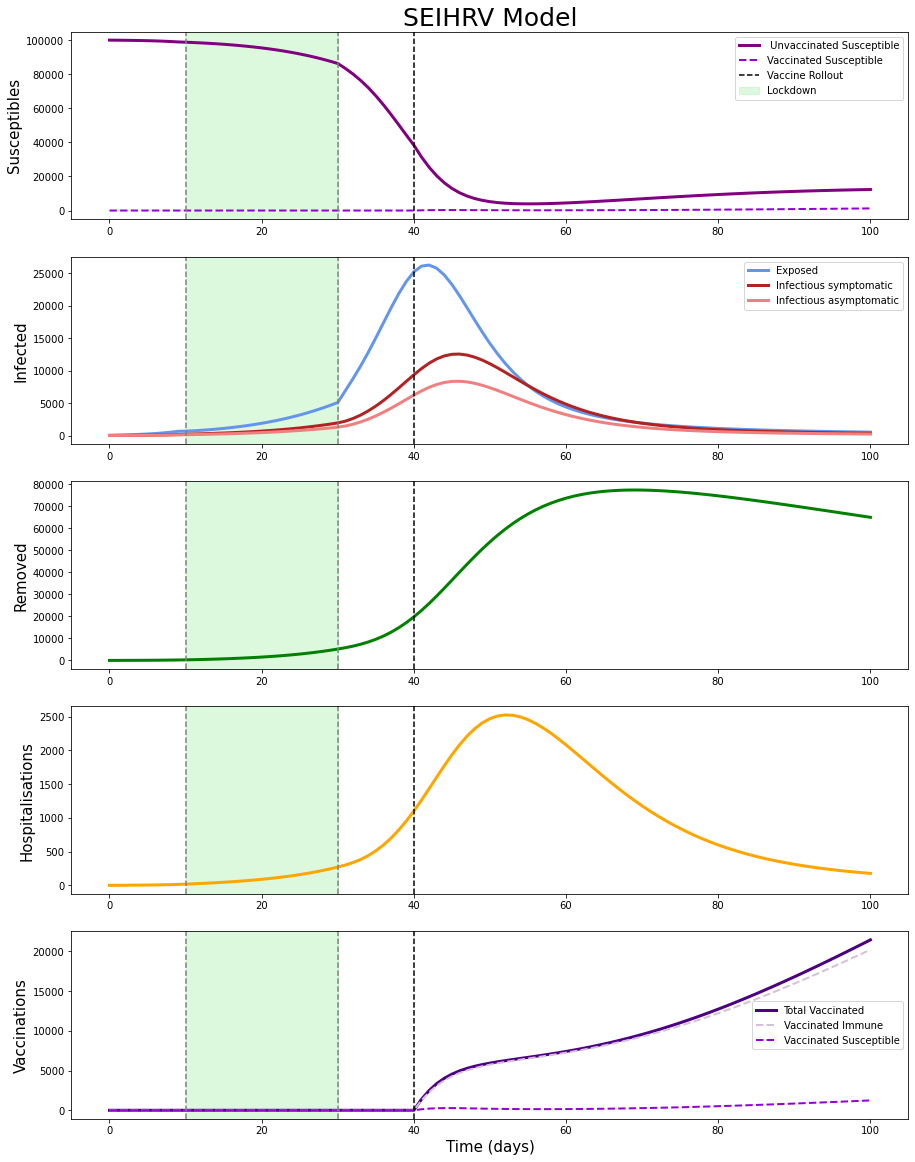

In [22]:
#Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/5 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 99900
E0 = 50
I_S0 = 25
I_A0 = 25
H0 = 0
R0 = 0
V_I0 = 0
V_S0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04  
eta = 0.9
vaccineStart = 40

# Lockdown parameters
lockdownStart = 10
lockdownEnd = 30
compliance = 2 #what we divide transmission rate by to simulate lockdown


InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V_I0, V_S0]


# Ordering the given times
times = [lockdownStart, lockdownEnd, vaccineStart]
t1 = min(times)
t3 = max(times)

for t in [t1,t3]:
    while t in times:
        times.remove(t)
        
t2 = times[0] #converting it to a number instead of an array of 1 elt


# We have four time arrays - for different vaccination/lockdown combinations
time1 = np.arange(t_start, t1, t_step) 
time2 = np.arange(t1 - t_step, t2 + t_step, t_step)
time3 = np.arange(t2, t3 + t_step, t_step)
time4 = np.arange(t3, days + t_step, t_step)


#The vaccination and non-vaccination functions, SEIHRmodel and SEIHRVmodel:
def SEIHRmodel(IVS,time, beta):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI * IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = 0
    V_S = 0
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

def SEIHRVmodel(IVS,time, beta):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * (IVS[0]+IVS[7])/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = sigma*eta*IVS[0]
    V_S = sigma*(1-eta)*IVS[0] - FOI*IVS[7]/N
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

#depending on which times denote lockdown/vaccine, we want to call different functions:
if t1 == lockdownStart:
    if t2 == vaccineStart:
        #then t3 is lockdown end
        values1 = spi.odeint(SEIHRmodel, InitialVals, time1, args=(beta,)) # pre-vaccine, no LD 
        values2 = spi.odeint(SEIHRmodel, values1[-1], time2, args=(beta/compliance,)) #pre-vaccine, with LD
        values3 = spi.odeint(SEIHRVmodel, values2[-1], time3, args=(beta/compliance,)) # post-vaccine, with LD
        values4 = spi.odeint(SEIHRVmodel, values3[-1], time4, args=(beta,)) # post-vaccine, no LD
    else:
        #t2 is lockdown end and t3 is vaccine start
        values1 = spi.odeint(SEIHRmodel, InitialVals, time1, args=(beta,)) # pre-vaccine, no LD 
        values2 = spi.odeint(SEIHRmodel, values1[-1], time2, args=(beta/compliance,)) #pre-vaccine, with LD
        values3 = spi.odeint(SEIHRmodel, values2[-1], time3, args=(beta,)) # pre-vaccine, no LD
        values4 = spi.odeint(SEIHRVmodel, values3[-1], time4, args=(beta,)) # post-vaccine, no LD
else:
    #t1 must be vaccineStart (the smallest time cannot be the END of the lockdown)
    #this means t2 must be lockdown start, t3 lockdown end. 
    values1 = spi.odeint(SEIHRmodel, InitialVals, time1, args=(beta,)) # pre-vaccine, no LD 
    values2 = spi.odeint(SEIHRVmodel, values1[-1], time2, args=(beta,)) #post-vaccine, no LD
    values3 = spi.odeint(SEIHRVmodel, values2[-1], time3, args=(beta/compliance,)) # post-vaccine, with LD
    values4 = spi.odeint(SEIHRVmodel, values3[-1], time4, args=(beta,)) # post-vaccine, no LD


total_values = np.concatenate((values1, values2[1:], values3[1:], values4[1:])) # Combining all info
total_vaccinated = total_values[:,6] + total_values[:,7]



# Plotting:
plt.figure(figsize=(15, 20))

plt.subplot(511)
plt.plot(total_values[:,0], 'purple', linewidth = 3, label = " Unvaccinated Susceptible")
plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed', label = 'Vaccine Rollout')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.title('SEIHRV Model', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(512)
plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Exposed')
plt.plot(total_values[:,2], 'firebrick', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(total_values[:,3], 'lightcoral', linewidth = 3, label = 'Infectious asymptomatic')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(513)
plt.plot(total_values[:,5], 'green', linewidth = 3, label='Removed')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.ylabel('Removed', fontsize=15)

plt.subplot(514)
plt.plot(total_values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(515)
plt.plot(total_vaccinated, 'indigo', linewidth = 3, label='Total Vaccinated')
plt.plot(total_values[:,6], 'thistle', linewidth = 2, linestyle = "--", label='Vaccinated Immune')
plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()

The problem with this is that the curves are not very continuous - there is no gradual ease in/out of lockdown. The code itself is also not very optimised, and adding any more information would get even more confusing. So I'm now going to try and find a better/cleaner way of doing this

I have found the following equation for $\beta(t)$, for $t >$`lockdownStart`. It satisfies the condition that at $t=$`lockdownStart`, $\beta(t-LS)=\beta$, and as $t \rightarrow \infty, \beta(t) = \frac{\beta}{c}$.

$$
\beta(t) = \frac{\beta}{c} + \frac{\beta (c-1)}{c}e^{-(t-LS)}
$$

Where $LS$ is lockdownStart.

I have used this to define a function `betaFunc(time)`, that for `lockdownStart < time < lockdownEnd` returns the value of this equation for $\beta(t)$, and otherwise just returns $\beta$. This gradually reduces beta to the new transmission rate of $\frac{\beta}{c}$. This then means that, once lockdown is over, transmission shoots back up to $\beta$ immediately. So for `time > lockdownEnd`, use the following function:

$$
\beta'(t) = \beta + \frac{\beta (1-c)}{c}e^{-k(t-LE)} 
$$
Where $LE$ is lockdownEnd, and $k \in (0,1]$ adjusts the speed of lockdown easing (closer to 0 is slower).

Since `betaFunc(time)` is continuous, you can just put it into the SEIHR(V) model functions and the ODE solver will use them appropriately. 

The lockdown period is also now shaded in light green on the graph.

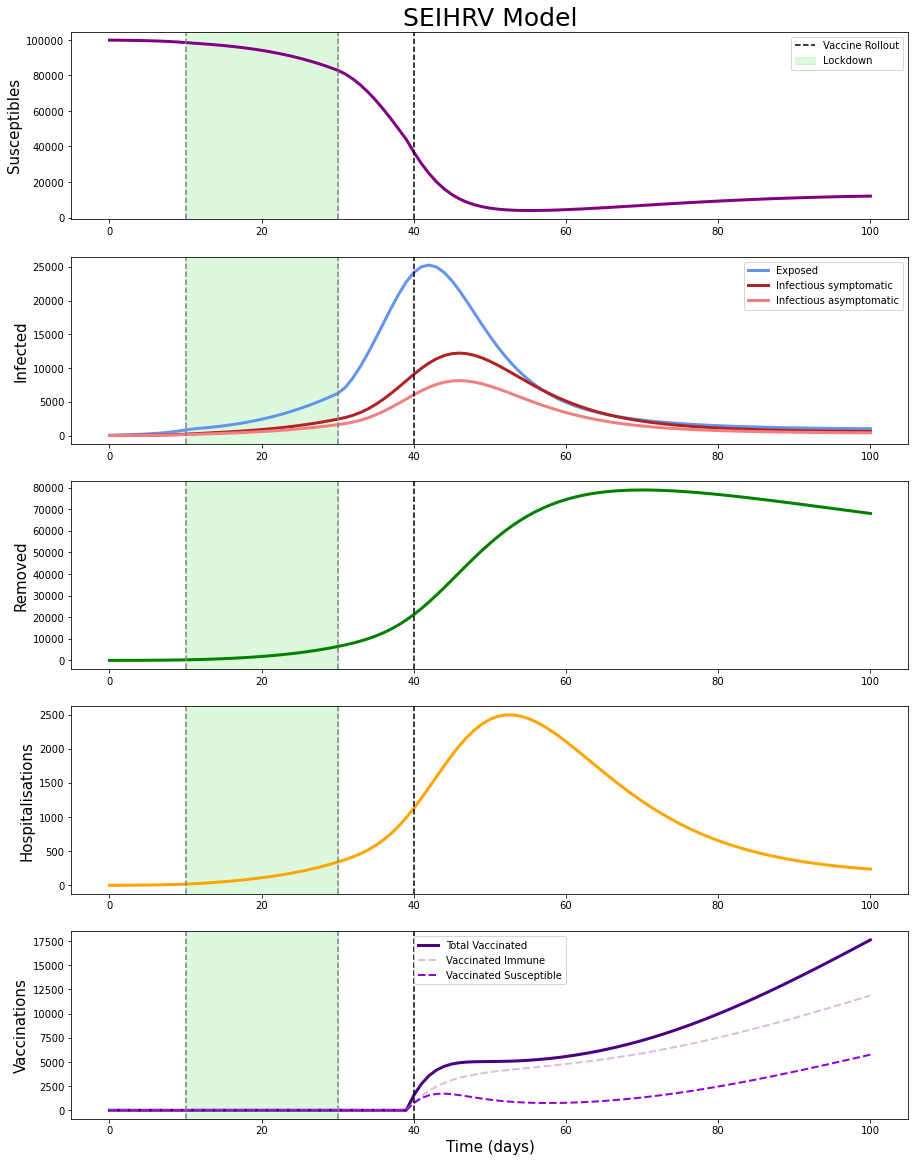

In [25]:
#Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/5 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 99900
E0 = 50
I_S0 = 25
I_A0 = 25
H0 = 0
R0 = 0
V_I0 = 0
V_S0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04  
eta = 0.5
vaccineStart = 40

# Lockdown parameters
lockdownStart = 10
lockdownEnd = 30  # must be > lockdownStart
compliance = 2    # what we divide transmission rate by to simulate lockdown (must be >1)
easing = 0.5      # rate of easing lockdown

InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V_I0, V_S0]

def betaFunc(time):
    if lockdownStart < time <= lockdownEnd:
        newBeta = (beta/compliance)*(1 + (compliance - 1)*np.exp(-(time - lockdownStart)))
    elif time > lockdownEnd:
        newBeta = beta + (beta*(1-compliance)/compliance)*np.exp(-easing*(time - lockdownEnd))
    else:
        newBeta = beta
    return newBeta

#The vaccination and non-vaccination functions, SEIHRmodel and SEIHRVmodel:
def SEIHRmodel(IVS,time):  
    
    FOI = betaFunc(time)*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI * IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = 0
    V_S = 0
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

def SEIHRVmodel(IVS,time):  
    
    FOI = betaFunc(time)*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * (IVS[0]+IVS[7])/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = sigma*eta*IVS[0]
    V_S = sigma*(1-eta)*IVS[0] - FOI*IVS[7]/N
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

t1 = np.arange(t_start, vaccineStart, t_step) # time up until vaccine implemented
t2 = np.arange(vaccineStart - t_step, days + t_step, t_step) # time after vaccine implemented

values1 = spi.odeint(SEIHRmodel, InitialVals, t1) # pre-vaccine 
values2 = spi.odeint(SEIHRVmodel, values1[-1], t2) # post-vaccine


total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info
total_vaccinated = total_values[:,6] + total_values[:,7]

# PLOTTING:

# Plotting:
plt.figure(figsize=(15, 20))

plt.subplot(511)
plt.plot(total_values[:,0], 'purple', linewidth = 3)
#plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed', label = 'Vaccine Rollout')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.title('SEIHRV Model', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(512)
plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Exposed')
plt.plot(total_values[:,2], 'firebrick', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(total_values[:,3], 'lightcoral', linewidth = 3, label = 'Infectious asymptomatic')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(513)
plt.plot(total_values[:,5], 'green', linewidth = 3, label='Removed')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.ylabel('Removed', fontsize=15)

plt.subplot(514)
plt.plot(total_values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(515)
plt.plot(total_vaccinated, 'indigo', linewidth = 3, label='Total Vaccinated')
plt.plot(total_values[:,6], 'thistle', linewidth = 2, linestyle = "--", label='Vaccinated Immune')
plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()

## Improved SEIHRDV model with 15 components and NGM rates

Using the new SEIHRDV model but adding lockdown.

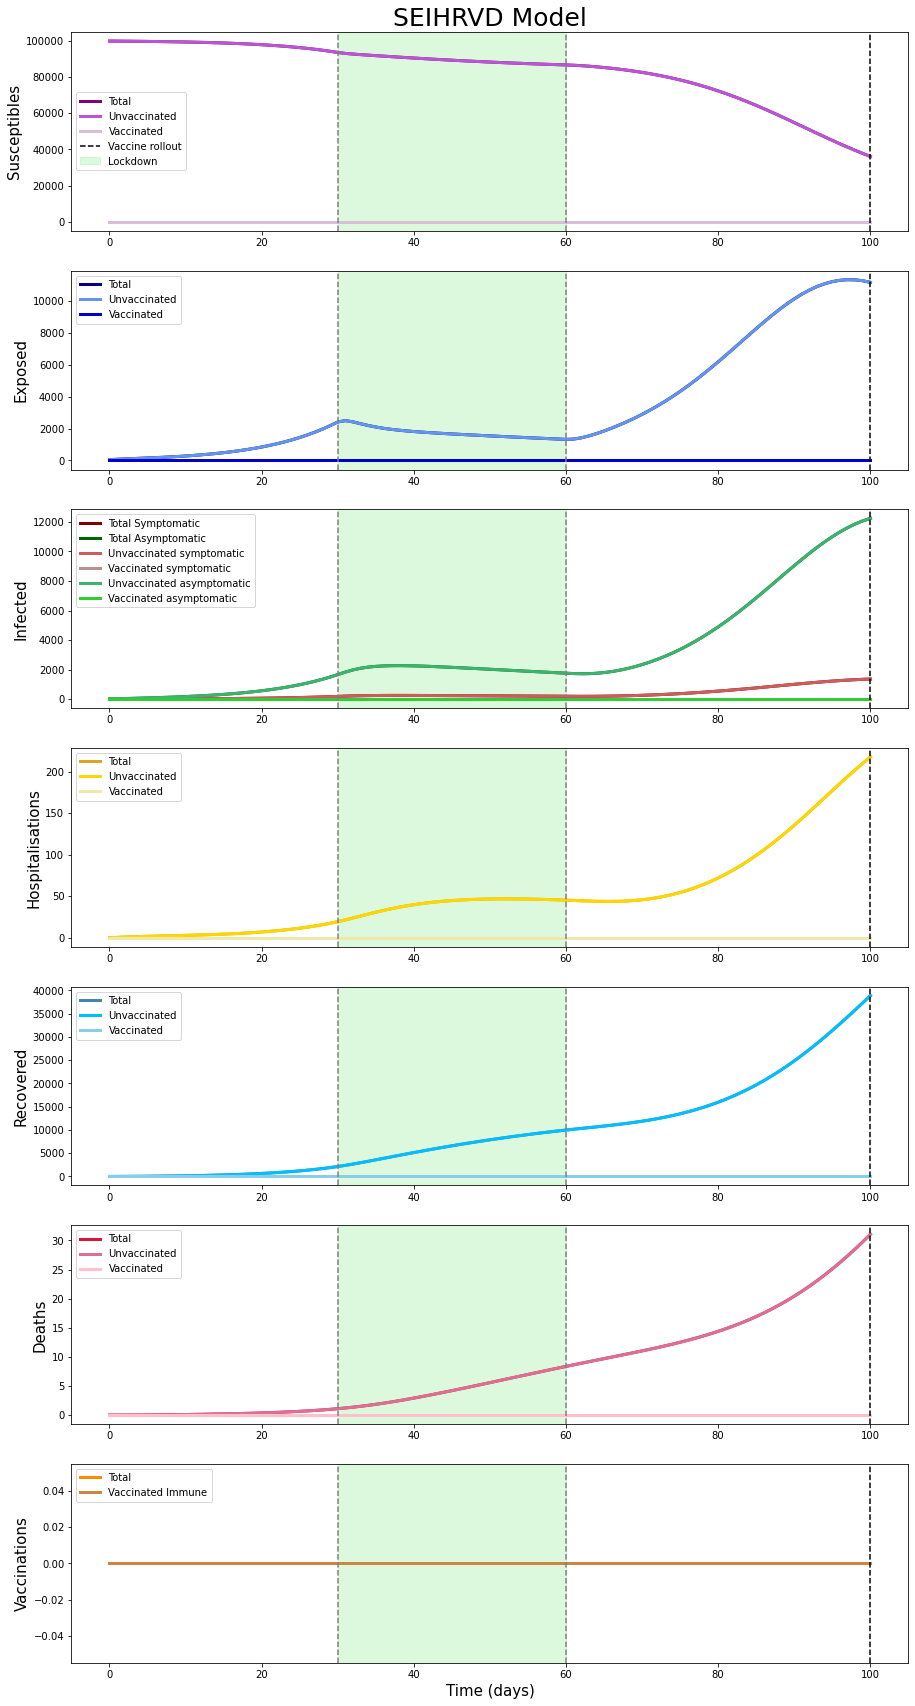

In [48]:
# Rates
beta = 1.24 
epsilon = 1/5.28
gamma = 1/7
delta = 1/10 
tau = 0.25 
rho = 0.1
omega = 1/100
k =  0.06  # probability of death (given hospitalisation)
d = 0.1
h1 = 0.15  # probability of hospitalisation given not vaccinated
h2 = 0.15  # probability of hospitalisation given vaccinated

# Population sizes
N = 100000 
# Unvaccinated populations:
S_U0 = 99900
E_U0 = 50
I_SU0 = 25
I_AU0 = 25
H_U0 = 0
R_U0 = 0
D_U0 = 0
# Vaccinated populations:
S_V0 = 0
S_VI0 = 0
E_V0 = 0
I_SV0 = 0
I_AV0 = 0
H_V0 = 0
R_V0 = 0
D_V0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04
eta = 0.7
vaccineStart = 30

# Lockdown parameters
lockdownStart = 30
lockdownEnd = 60  # must be > lockdownStart
compliance = 3    # what we divide transmission rate by to simulate lockdown (must be >3 to make R0<1)
easing = 0.2      # rate of easing lockdown


def betaFunc(time):
    if lockdownStart < time <= lockdownEnd:
        newBeta = (beta/compliance)*(1 + (compliance - 1)*np.exp(-(time - lockdownStart)))
    elif time > lockdownEnd:
        newBeta = beta + (beta*(1-compliance)/compliance)*np.exp(-easing*(time - lockdownEnd))
    else:
        newBeta = beta
    return newBeta

InitialVals = [S_U0, E_U0, I_SU0, I_AU0, H_U0, R_U0, D_U0, S_V0, S_VI0, E_V0, I_SV0, I_AV0, H_V0, R_V0, D_V0]

# SEIHR model with vaccination set to 0
def SEIHRmodel(IVS,time):  
    
    FOI = betaFunc(time)*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S_U  = omega*IVS[5] - FOI*IVS[0]/N
    E_U  = FOI*IVS[0]/N - epsilon*IVS[1]
    I_SU = epsilon*d*IVS[1] - gamma*IVS[2]
    I_AU = epsilon*(1-d)*IVS[1] - gamma*IVS[3]
    H_U  = gamma*h1*IVS[2] - delta*IVS[4]
    R_U  = delta*(1-k)*IVS[4] + gamma*(1-h1)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    D_U  = delta*k*IVS[4]
    
    S_V  = 0
    S_VI = 0
    E_V  = 0
    I_SV = 0
    I_AV = 0
    H_V  = 0
    R_V  = 0
    D_V  = 0
    
    Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
    return(Y) 

# SEIHRV model, adding vaccine
def SEIHRVmodel(IVS,time): 
    
    FOI = betaFunc(time)*(tau*(IVS[3] + IVS[11]) + IVS[2] + IVS[10] + rho*(IVS[4] + IVS[12]))
    
    S_U  = omega*IVS[5] - FOI*IVS[0]/N - sigma*IVS[0]
    E_U  = FOI*IVS[0]/N - epsilon*IVS[1]
    I_SU = epsilon*d*IVS[1] - gamma*IVS[2]
    I_AU = epsilon*(1-d)*IVS[1] - gamma*IVS[3]
    H_U  = gamma*h1*IVS[2] - delta*IVS[4]
    R_U  = delta*(1-k)*IVS[4] + gamma*(1-h1)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    D_U  = delta*k*IVS[4]
    
    S_V  = omega*IVS[13] - FOI*IVS[7]/N + sigma*(1-eta)*IVS[0]
    S_VI = sigma*eta*IVS[0]
    E_V  = FOI*IVS[7]/N - epsilon*IVS[9]
    I_SV = epsilon*d*IVS[9] - gamma*IVS[10]
    I_AV = epsilon*(1-d)*IVS[9] - gamma*IVS[11]
    H_V  = gamma*h2*IVS[10] - delta*IVS[12]
    R_V  = delta*(1-k)*IVS[12] + gamma*(1-h2)*IVS[10] + gamma*IVS[11] - omega*IVS[13]
    D_V  = delta*k*IVS[12]
    
    Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
    return(Y) 


t1 = np.arange(t_start, vaccineStart, t_step) # time up until vaccine implemented
t2 = np.arange(vaccineStart - t_step, days + t_step, t_step) # time after vaccine implemented

values1 = spi.odeint(SEIHRmodel, InitialVals, t1) # pre-vaccine 
values2 = spi.odeint(SEIHRVmodel, values1[-1], t2) # post-vaccine

total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

# Getting the totals
total_susceptible = total_values[:,0] + total_values[:,7]
total_exposed = total_values[:,1] + total_values[:,9]
total_infectedS = total_values[:,2] + total_values[:,10]
total_infectedA = total_values[:,3] + total_values[:,11]
total_hospitalised = total_values[:,4] + total_values[:,12]
total_recovered = total_values[:,5] + total_values[:,13]
total_dead = total_values[:,6] + total_values[:, 14]
total_vaccinated = total_values[:,7]+ total_values[:,8] + total_values[:,9]+ total_values[:,10] + total_values[:,11]+ total_values[:,12] + total_values[:,11]+ total_values[:,12]

# Plotting:
plt.figure(figsize=(15, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(total_susceptible, 'purple', linewidth = 3, label = 'Total')
plt.plot(total_values[:,0], 'mediumorchid', linewidth = 3, label = 'Unvaccinated')
plt.plot(total_values[:,7], 'thistle', linewidth = 3, label = 'Vaccinated')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed', label = 'Vaccine rollout')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.title('SEIHRVD Model', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(total_exposed, 'darkblue', linewidth=3, label = 'Total')
plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,9], 'mediumblue', linewidth = 3, label='Vaccinated')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(total_infectedS, 'maroon', linewidth=3, label = 'Total Symptomatic')
plt.plot(total_infectedA, 'darkgreen', linewidth=3, label = 'Total Asymptomatic')
plt.plot(total_values[:,2], 'indianred', linewidth = 3, label = 'Unvaccinated symptomatic')
plt.plot(total_values[:,10], 'rosybrown', linewidth = 3, label = 'Vaccinated symptomatic')
plt.plot(total_values[:,3], 'mediumseagreen', linewidth = 3, label = 'Unvaccinated asymptomatic')
plt.plot(total_values[:,11], 'limegreen', linewidth = 3, label = 'Vaccinated asymptomatic')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
plt.plot(total_hospitalised, 'goldenrod', linewidth=3, label = 'Total')
plt.plot(total_values[:,4], 'gold', linewidth = 3, label = 'Unvaccinated')
plt.plot(total_values[:,12], 'palegoldenrod', linewidth = 3, label = 'Vaccinated')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(total_recovered, 'steelblue', linewidth=3, label = 'Total')
plt.plot(total_values[:,5], 'deepskyblue', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,13], 'skyblue', linewidth = 3, label='Vaccinated')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(total_dead, 'crimson', linewidth=3, label = 'Total')
plt.plot(total_values[:,6], 'palevioletred', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,14], 'pink', linewidth = 3, label='Vaccinated')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(total_vaccinated, 'darkorange', linewidth = 3, label='Total')
plt.plot(total_values[:,8], 'peru', linewidth = 3, label='Vaccinated Immune')
plt.axvline(vaccineStart, color = 'black', linestyle='dashed')
plt.axvline(lockdownStart, color = 'grey', linestyle='dashed')
plt.axvline(lockdownEnd, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdownStart, xmax=lockdownEnd, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()